# Análise Exploratória de Dados — Overhead de Ofuscação (Allatori)

Aplicada aos dados **reais** deste repositório, já limpos e tipados na etapa anterior (`analysis-data-preparation.ipynb` → `analysis/summary_prepared.csv` e `analysis/arch_interaction_prepared.csv`).

Esta análise segue os mesmos passos do notebook de referência [Aula03_Analise_Exploratoria_dados.ipynb](Aula03_Analise_Exploratoria_dados.ipynb) — visualizações, medidas de posição e dispersão, `describe()`, correlação de Pearson/Spearman e a lição do quarteto de Anscombe — aplicados ao overhead de tempo de execução introduzido por cada perfil de ofuscação (`baseline`, `flow`, `string`, `flowstring`) em relação ao `original`, nas arquiteturas x86_64 e aarch64.

<hr>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from scipy.stats import iqr, pearsonr, spearmanr

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["font.size"] = 12
pd.set_option("display.max_columns", 30)

summary = pd.read_csv("analysis/summary_prepared.csv")
arch_interaction = pd.read_csv("analysis/arch_interaction_prepared.csv")

ordem_perfis = ["original", "baseline", "flow", "string", "flowstring"]
summary["profile"] = pd.Categorical(summary["profile"], categories=ordem_perfis, ordered=True)
arch_interaction["profile"] = pd.Categorical(arch_interaction["profile"], categories=ordem_perfis, ordered=True)

# Para a EDA de overhead, focamos nas linhas comparáveis (excluímos "original",
# que é a própria referência e tem overhead = 0 por definição — ver preparação).
obf = summary[summary["profile"] != "original"].copy()

print("summary:", summary.shape, "| linhas obfuscadas (sem 'original'):", obf.shape)
summary.head()

summary: (30, 18) | linhas obfuscadas (sem 'original'): (24, 18)


,arch,size,profile,mean,ci_lo,ci_hi,unit,overhead_%_vs_original,overhead_ci_lo,overhead_ci_hi,test,p_value,cliffs_delta,n_forks,p_value_holm,significant_5%,is_baseline,profile_level
0,aarch64,5000,baseline,1230.6997,1213.3711,1248.0283,us/op,-0.07,-1.58,1.48,welch-t,0.930695,-0.02,10,0.930695,False,False,1
1,aarch64,5000,flow,1217.0310,1203.3168,1230.7451,us/op,-1.18,-2.59,0.15,welch-t,0.126301,-0.34,10,0.252603,False,False,2
2,aarch64,5000,flowstring,1834.9413,1778.8414,1891.0412,us/op,48.99,45.13,53.25,welch-t,0.000000,1.00,10,0.000000,True,False,4
3,aarch64,5000,original,1231.6012,1216.3001,1246.9022,us/op,0.00,NaN,NaN,NaN,NaN,NaN,10,NaN,False,True,0
4,aarch64,5000,string,1837.8063,1786.7540,1888.8587,us/op,49.22,45.66,53.10,welch-t,0.000000,1.00,10,0.000000,True,False,3


## 1. Visualização de dados

A variável central desta análise é `overhead_%_vs_original`: quanto (em %) o tempo de execução de um perfil ofuscado aumenta em relação ao jar original, para uma dada arquitetura e tamanho de carga (`size`). As variáveis categóricas são `profile` (intensidade da ofuscação) e `arch`.

### 1.1 Histograma de frequências

Distribuição de `overhead_%_vs_original` entre as 24 combinações (arch × size × perfil ofuscado, excluindo `original`).

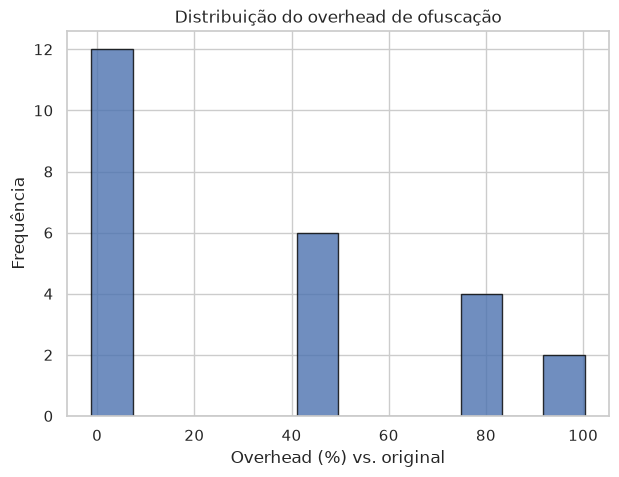

In [2]:
plt.figure(figsize=(7, 5))
plt.hist(obf["overhead_%_vs_original"], bins=12, density=False, edgecolor="black", alpha=0.8)
plt.xlabel("Overhead (%) vs. original")
plt.ylabel("Frequência")
plt.title("Distribuição do overhead de ofuscação")
plt.show()

O histograma já sugere uma distribuição **bimodal**: um agrupamento próximo de 0% (perfis `baseline`/`flow`, que só renomeiam e alteram o fluxo de controle) e outro entre 45% e 100% (perfis `string`/`flowstring`, que também criptografam strings). Isso é investigado com mais detalhe na Seção 1.2.

### 1.2 Histograma normalizado, separado por técnica de ofuscação

Normalizamos (`density=True`) e sobrepomos as duas famílias de perfil: com e sem criptografia de strings. Isso confirma a bimodalidade como um efeito real da técnica aplicada, não um artefato dos *bins* escolhidos.

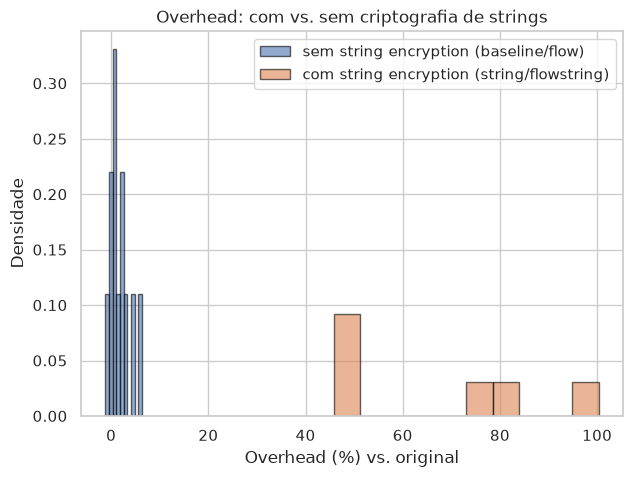

In [3]:
sem_string = obf[obf["profile"].isin(["baseline", "flow"])]["overhead_%_vs_original"]
com_string = obf[obf["profile"].isin(["string", "flowstring"])]["overhead_%_vs_original"]

plt.figure(figsize=(7, 5))
plt.hist(sem_string, bins=10, density=True, alpha=0.6, edgecolor="black", label="sem string encryption (baseline/flow)")
plt.hist(com_string, bins=10, density=True, alpha=0.6, edgecolor="black", label="com string encryption (string/flowstring)")
plt.xlabel("Overhead (%) vs. original")
plt.ylabel("Densidade")
plt.title("Overhead: com vs. sem criptografia de strings")
plt.legend()
plt.show()

As duas famílias praticamente não se sobrepõem: o **controle de fluxo** (`flow`) é quase gratuito em termos de tempo de execução, enquanto a **criptografia de strings** (`string`) domina o overhead — combiná-la com controle de fluxo (`flowstring`) não soma efeitos visíveis (ver Seção 5 e 7).

### 1.3 Gráfico de barras para variável categórica

`profile` é categórica com ordem natural de intensidade. Um gráfico de barras do overhead médio por perfil resume a tendência central de cada grupo.

profile
baseline       1.426667
flow           1.990000
string        66.636667
flowstring    66.146667
Name: overhead_%_vs_original, dtype: float64


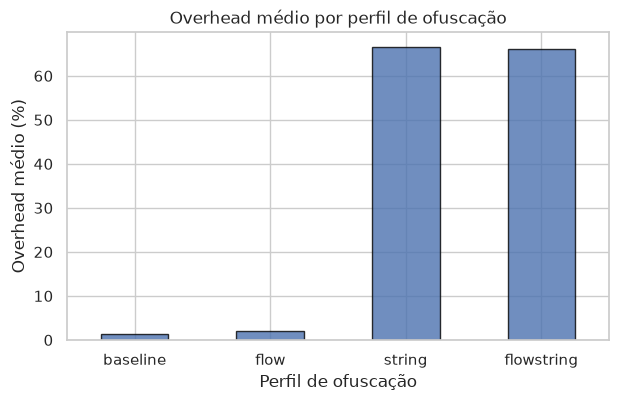

In [4]:
overhead_medio = obf.groupby("profile", observed=True)["overhead_%_vs_original"].mean().reindex(
    ["baseline", "flow", "string", "flowstring"]
)
print(overhead_medio)

plt.figure(figsize=(7, 4))
overhead_medio.plot(kind="bar", edgecolor="black", alpha=0.8)
plt.xlabel("Perfil de ofuscação")
plt.ylabel("Overhead médio (%)")
plt.title("Overhead médio por perfil de ofuscação")
plt.xticks(rotation=0)
plt.show()

### 1.4 Gráfico de setores

Proporção de combinações (arch, size, perfil) em que o overhead é estatisticamente significativo a 5% (`significant_5%`, já corrigido por Holm-Bonferroni).

significant_5%
significativo        18
não significativo     6
Name: count, dtype: int64


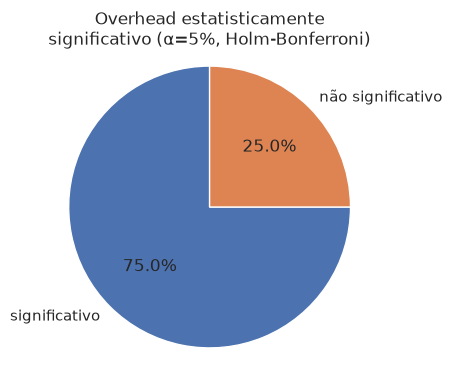

In [5]:
frequencias_sig = obf["significant_5%"].value_counts()
frequencias_sig.index = frequencias_sig.index.map({True: "significativo", False: "não significativo"})
print(frequencias_sig)

plt.figure(figsize=(4, 4))
plt.pie(frequencias_sig.values, labels=frequencias_sig.index, autopct="%1.1f%%", startangle=90)
plt.title("Overhead estatisticamente\nsignificativo (α=5%, Holm-Bonferroni)")
plt.axis("equal")
plt.show()

A maioria das combinações mostra overhead estatisticamente significativo — inclusive alguns casos de `baseline`/`flow` com overhead pequeno em magnitude, mas ainda assim detectável (ver Seção 7, onde isso é desmembrado por arquitetura).

### 1.5 Scatterplot

Relação entre `size` (tamanho da carga de ordens) e `overhead_%_vs_original`, colorindo por perfil, com formato do marcador indicando a arquitetura.

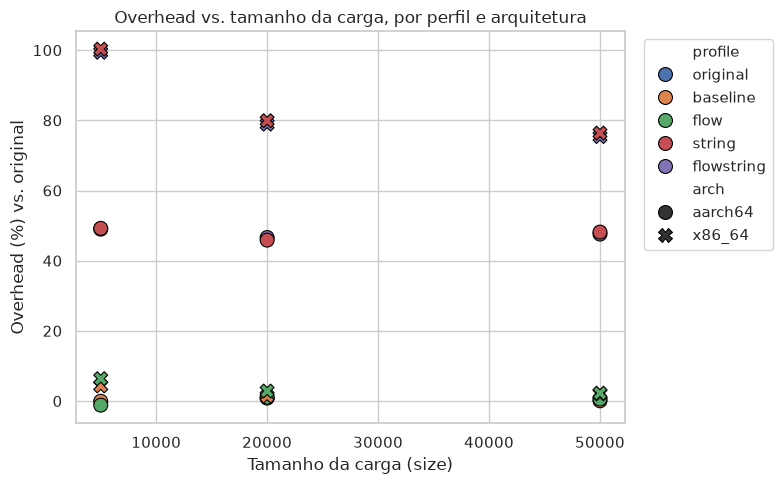

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=obf, x="size", y="overhead_%_vs_original",
    hue="profile", style="arch", s=100, edgecolor="black"
)
plt.xlabel("Tamanho da carga (size)")
plt.ylabel("Overhead (%) vs. original")
plt.title("Overhead vs. tamanho da carga, por perfil e arquitetura")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Os dois clusters (perto de 0% e entre 45–100%) se separam claramente por perfil, não por tamanho de carga — `size` não parece ser o principal fator explicativo do overhead (isso é confirmado quantitativamente na Seção 6).

### 1.6 Mapa de calor

Tabela dinâmica de overhead médio por (arquitetura × perfil), representada como mapa de calor.

arch          aarch64     x86_64
profile                         
baseline     0.280000   2.573333
flow         0.153333   3.826667
string      47.746667  85.526667
flowstring  47.726667  84.566667


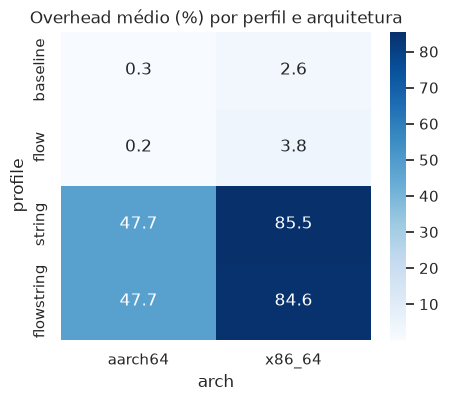

In [7]:
tabela_overhead = obf.pivot_table(
    index="profile", columns="arch", values="overhead_%_vs_original", observed=True
).reindex(["baseline", "flow", "string", "flowstring"])
print(tabela_overhead)

plt.figure(figsize=(5, 4))
sns.heatmap(tabela_overhead, annot=True, fmt=".1f", cmap="Blues")
plt.title("Overhead médio (%) por perfil e arquitetura")
plt.show()

O mapa de calor evidencia um segundo padrão, ortogonal ao efeito do perfil: em todo perfil, x86_64 tem overhead maior que aarch64 — consistente com `arch_interaction.csv` (T8), que mede exatamente essa diferença entre arquiteturas.

## 2. Medidas de posição

### 2.1 Moda

`profile` e `arch` são balanceados por construção (fatorial completo, ver preparação), então a moda de `profile` é multimodal — todo perfil aparece o mesmo número de vezes. O `test` estatístico usado (Welch-t vs. Mann-Whitney), por outro lado, depende da normalidade dos dados (Shapiro-Wilk, `scripts/07_analyze.py`) e não é balanceado — sua moda é informativa.

Frequências de 'test': Counter({'welch-t': 18, 'mann-whitney': 6})
Moda: welch-t — aparece 18 de 24 vezes


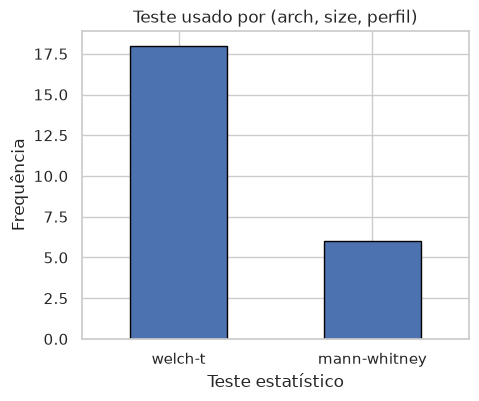

In [8]:
contagem_teste = Counter(obf["test"].dropna())
moda_teste = contagem_teste.most_common(1)[0]

print("Frequências de 'test':", contagem_teste)
print(f"Moda: {moda_teste[0]} — aparece {moda_teste[1]} de {obf['test'].notna().sum()} vezes")

pd.Series(contagem_teste).plot(kind="bar", figsize=(5, 4), edgecolor="black")
plt.xlabel("Teste estatístico")
plt.ylabel("Frequência")
plt.title("Teste usado por (arch, size, perfil)")
plt.xticks(rotation=0)
plt.show()

### 2.2 Média e mediana por perfil

Como cada perfil mistura duas arquiteturas com overheads bem diferentes (Seção 1.6), média e mediana já divergem mesmo sem nenhum valor "errado" — a diferença vem da mistura de subpopulações, não de outliers espúrios.

In [9]:
posicao_por_perfil = obf.groupby("profile", observed=True)["overhead_%_vs_original"].agg(
    media="mean", mediana="median"
).reindex(["baseline", "flow", "string", "flowstring"])
posicao_por_perfil["diferenca"] = posicao_por_perfil["media"] - posicao_por_perfil["mediana"]
posicao_por_perfil

,media,mediana,diferenca
profile,,,
baseline,1.426667,1.115,0.311667
flow,1.990000,1.655,0.335000
string,66.636667,62.800,3.836667
flowstring,66.146667,62.185,3.961667


### 2.3 Média e mediana em cada arquitetura

Ao condicionar em `arch`, a mistura desaparece e as distribuições ficam mais coerentes internamente — comparamos aqui como média e mediana se comportam em cada uma.

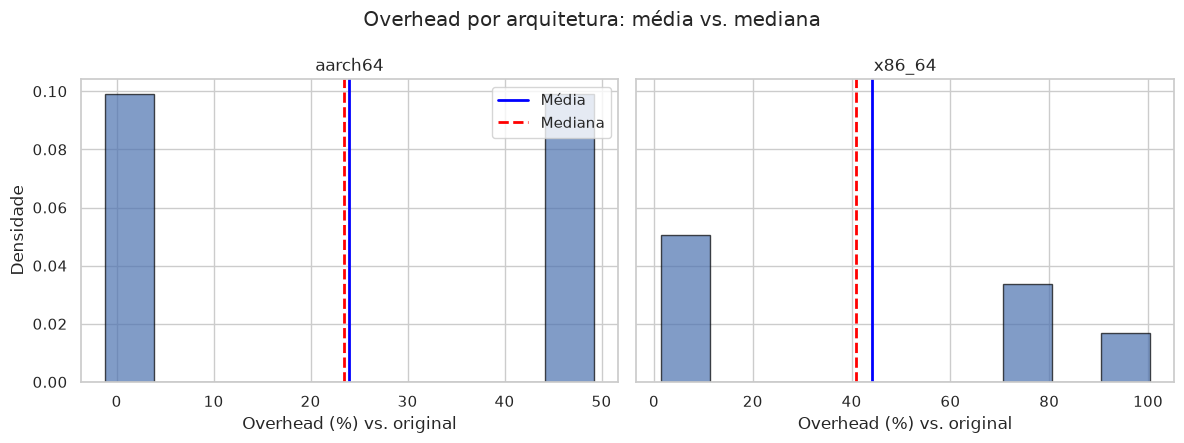

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, arquitetura in zip(axs, ["aarch64", "x86_64"]):
    dados_arch = obf.loc[obf["arch"] == arquitetura, "overhead_%_vs_original"]
    media_arch = dados_arch.mean()
    mediana_arch = dados_arch.median()

    ax.hist(dados_arch, bins=10, density=True, edgecolor="black", alpha=0.7)
    ax.axvline(media_arch, color="blue", linewidth=2, label="Média")
    ax.axvline(mediana_arch, color="red", linewidth=2, linestyle="--", label="Mediana")
    ax.set_title(arquitetura)
    ax.set_xlabel("Overhead (%) vs. original")

axs[0].set_ylabel("Densidade")
axs[0].legend()
plt.suptitle("Overhead por arquitetura: média vs. mediana")
plt.tight_layout()
plt.show()

Em ambas as arquiteturas a distribuição é bimodal (herdada dos dois grupos de perfil), então nem média nem mediana caem sobre um "centro" real dos dados — outra ilustração de por que a Seção 1 (histograma/scatter) é indispensável antes de confiar em qualquer estatística-resumo isolada.

### 2.4 Quantis

Quartis e IQR do overhead, para o conjunto completo de perfis ofuscados.

In [11]:
overhead = obf["overhead_%_vs_original"]

q1 = np.quantile(overhead, 0.25)
q2 = np.quantile(overhead, 0.50)
q3 = np.quantile(overhead, 0.75)

print("Primeiro quartil Q1:", round(q1, 2))
print("Mediana Q2:", round(q2, 2))
print("Terceiro quartil Q3:", round(q3, 2))
print("IQR:", round(q3 - q1, 2))

Primeiro quartil Q1: 1.31
Mediana Q2: 26.12
Terceiro quartil Q3: 55.76
IQR: 54.45


O IQR é enorme (dezenas de pontos percentuais) porque Q1 cai dentro do cluster "sem string encryption" e Q3 dentro do cluster "com string encryption" — mais um sintoma da bimodalidade, não uma dispersão real e contínua. Por isso o IQR só é interpretável de forma útil **dentro de cada perfil** (Seção 2.5 e 4).

### 2.5 Boxplot

Boxplot do overhead por perfil (ordem de intensidade crescente), agora sim revelando a dispersão *dentro* de cada grupo.

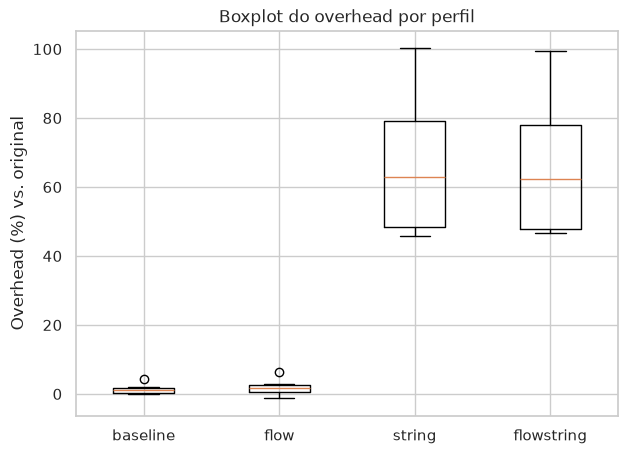

In [12]:
grupos = [obf.loc[obf["profile"] == p, "overhead_%_vs_original"] for p in ["baseline", "flow", "string", "flowstring"]]

plt.figure(figsize=(7, 5))
plt.boxplot(grupos, tick_labels=["baseline", "flow", "string", "flowstring"])
plt.ylabel("Overhead (%) vs. original")
plt.title("Boxplot do overhead por perfil")
plt.show()

## 3. Comparação entre grupos: perfil × arquitetura

Assim como a aula de referência usa a espécie da Iris para comparar grupos, aqui usamos `profile` (eixo x) e `arch` (cor) para comparar a distribuição do overhead entre os grupos reais do experimento — cada grupo tem apenas 3 observações (uma por `size`), então os gráficos abaixo já mostram os pontos individuais.

### 3.1 Boxplot por perfil, separado por arquitetura

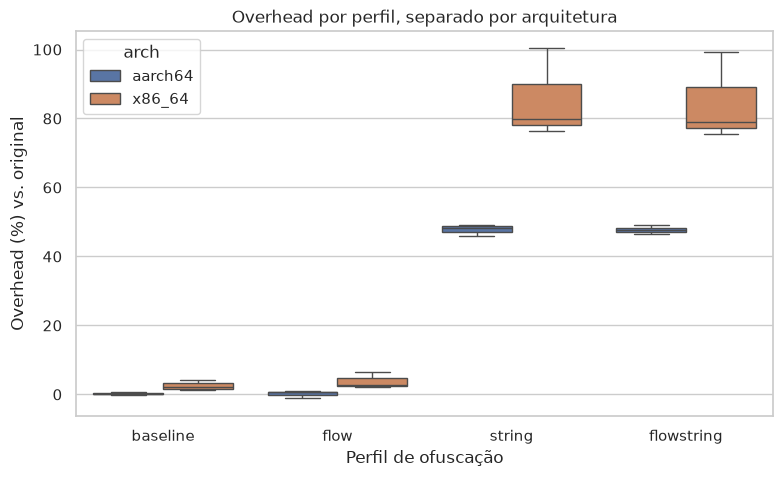

In [13]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=obf, x="profile", y="overhead_%_vs_original", hue="arch", order=["baseline", "flow", "string", "flowstring"])
plt.xlabel("Perfil de ofuscação")
plt.ylabel("Overhead (%) vs. original")
plt.title("Overhead por perfil, separado por arquitetura")
plt.show()

### 3.2 Violin plot

O violin plot acrescenta uma estimativa de densidade a cada grupo — com apenas 3 pontos por grupo, a "forma" deve ser lida com cautela, mas o gráfico ainda comunica bem o intervalo de valores.

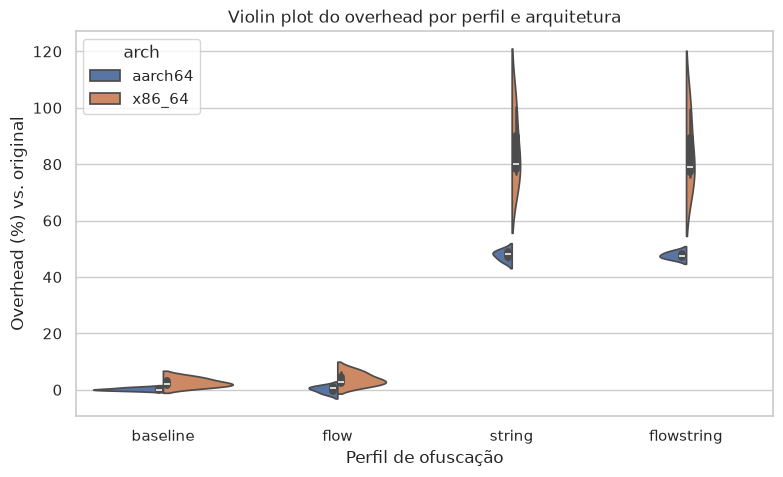

In [14]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=obf, x="profile", y="overhead_%_vs_original", hue="arch", order=["baseline", "flow", "string", "flowstring"], split=True)
plt.xlabel("Perfil de ofuscação")
plt.ylabel("Overhead (%) vs. original")
plt.title("Violin plot do overhead por perfil e arquitetura")
plt.show()

### 3.3 Swarm plot

Com apenas 3 observações por grupo (uma por `size`), o swarm plot mostra cada ponto individual — útil aqui para não esconder nenhuma das 3 réplicas por trás de um resumo estatístico.

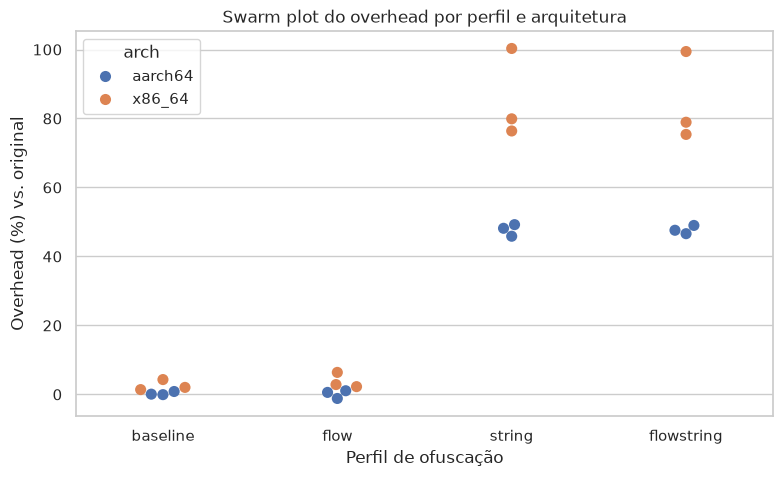

In [15]:
plt.figure(figsize=(9, 5))
sns.swarmplot(data=obf, x="profile", y="overhead_%_vs_original", hue="arch", order=["baseline", "flow", "string", "flowstring"], size=8)
plt.xlabel("Perfil de ofuscação")
plt.ylabel("Overhead (%) vs. original")
plt.title("Swarm plot do overhead por perfil e arquitetura")
plt.show()

## 4. Medidas de dispersão

Comparamos amplitude, variância amostral, desvio-padrão e IQR do overhead **dentro de cada perfil** (6 observações: 2 arquiteturas × 3 tamanhos).

In [16]:
def dispersao(valores):
    valores = np.asarray(valores)
    return pd.Series({
        "amplitude": valores.max() - valores.min(),
        "variancia": np.var(valores, ddof=1),
        "desvio_padrao": np.std(valores, ddof=1),
        "iqr": iqr(valores),
    })

dispersao_por_perfil = obf.groupby("profile", observed=True)["overhead_%_vs_original"].apply(dispersao).unstack()
dispersao_por_perfil = dispersao_por_perfil.reindex(["baseline", "flow", "string", "flowstring"])
dispersao_por_perfil

,amplitude,variancia,desvio_padrao,iqr
profile,,,,
baseline,4.37,2.609227,1.615310,1.6075
flow,7.56,6.596240,2.568315,2.0000
string,54.44,496.093187,22.273149,30.5950
flowstring,52.81,475.075947,21.796237,30.0875


A dispersão absoluta cresce junto com o overhead médio (`string`/`flowstring` têm desvio-padrão ~20 pontos percentuais, contra ~2 em `baseline`/`flow`) — mas isso não significa que os perfis com string encryption sejam "menos estáveis": grande parte dessa dispersão é o mesmo efeito sistemático de arquitetura visto na Seção 1.6 (x86_64 consistentemente mais caro que aarch64), não ruído experimental.

## 5. Resumo descritivo com Pandas

In [17]:
obf[["size", "mean", "overhead_%_vs_original", "p_value", "cliffs_delta"]].describe()

,size,mean,overhead_%_vs_original,p_value,cliffs_delta
count,24.000000,24.000000,24.000000,24.000000,24.000000
mean,25000.000000,4537.729317,34.050000,0.138337,0.723333
std,19110.661718,5439.583879,36.120058,0.297736,0.419427
min,5000.000000,182.148300,-1.180000,0.000000,-0.340000
25%,5000.000000,1115.992250,1.307500,0.000000,0.490000
50%,20000.000000,1964.457150,26.120000,0.000132,1.000000
75%,50000.000000,5643.991300,55.760000,0.065441,1.000000
max,50000.000000,18212.137000,100.300000,0.930695,1.000000


O resumo por grupo (`groupby(...).describe()`) é mais informativo aqui do que o resumo global acima, exatamente por causa da bimodalidade discutida na Seção 1 — compare `string` e `flowstring` entre si.

In [18]:
obf.groupby("profile", observed=True)["overhead_%_vs_original"].describe().reindex(
    ["baseline", "flow", "string", "flowstring"]
)

,count,mean,std,min,25%,50%,75%,max
profile,,,,,,,,
baseline,6.0,1.426667,1.615310,-0.07,0.2625,1.115,1.8700,4.30
flow,6.0,1.990000,2.568315,-1.18,0.7000,1.655,2.7000,6.38
string,6.0,66.636667,22.273149,45.86,48.4250,62.800,79.0200,100.30
flowstring,6.0,66.146667,21.796237,46.60,47.9400,62.185,78.0275,99.41


`string` (média 66,64%, desvio 22,27) e `flowstring` (média 66,15%, desvio 21,80) são quase indistinguíveis por essas estatísticas — o controle de fluxo, sozinho, quase não altera o overhead já dominado pela criptografia de strings. Isso é revisitado na Seção 7.

## 6. Correlação

Investigamos a associação entre `profile_level` (intensidade ordinal da ofuscação, ver preparação), `size`, `mean` (tempo absoluto), `overhead_%_vs_original`, `p_value` e `cliffs_delta`.

### 6.1 Correlação de Pearson: intensidade da ofuscação vs. overhead

In [19]:
corr_pearson, p_pearson = pearsonr(obf["profile_level"], obf["overhead_%_vs_original"])
corr_pearson_size, p_pearson_size = pearsonr(obf["size"], obf["overhead_%_vs_original"])

print(f"Pearson(profile_level, overhead) = {corr_pearson:.3f}  (p={p_pearson:.2e})")
print(f"Pearson(size, overhead)          = {corr_pearson_size:.3f}  (p={p_pearson_size:.2e})")

Pearson(profile_level, overhead) = 0.818  (p=1.03e-06)
Pearson(size, overhead)          = -0.071  (p=7.43e-01)


A intensidade da ofuscação (`profile_level`) tem correlação forte e positiva com o overhead (Pearson ≈ 0,82), enquanto `size` não tem associação linear relevante (Pearson ≈ -0,07, não significativo) — o overhead é dominado pela *técnica* aplicada, não pelo tamanho da carga processada.

### 6.2 Matriz de correlação

`n_forks` é excluída por ser constante (10 em todo o experimento, por desenho do benchmark T6) — sua correlação com qualquer variável é indefinida (desvio-padrão zero).

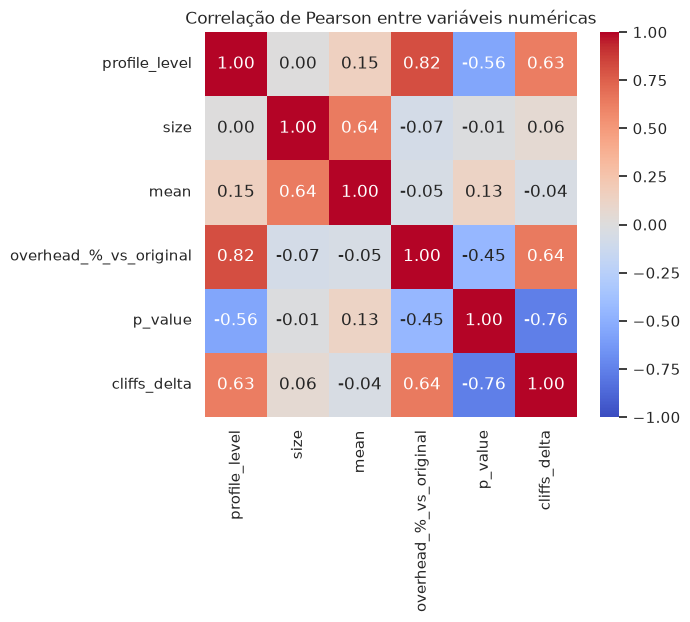

,profile_level,size,mean,overhead_%_vs_original,p_value,cliffs_delta
profile_level,1.000000e+00,3.261162e-17,0.154306,0.818321,-0.556625,0.631726
size,3.261162e-17,1.000000e+00,0.635781,-0.070737,-0.013706,0.056412
mean,1.543057e-01,6.357809e-01,1.000000,-0.052046,0.131040,-0.042835
overhead_%_vs_original,8.183211e-01,-7.073707e-02,-0.052046,1.000000,-0.452583,0.641997
p_value,-5.566246e-01,-1.370601e-02,0.131040,-0.452583,1.000000,-0.762580
cliffs_delta,6.317257e-01,5.641227e-02,-0.042835,0.641997,-0.762580,1.000000


In [20]:
colunas_numericas = ["profile_level", "size", "mean", "overhead_%_vs_original", "p_value", "cliffs_delta"]
corr = obf[colunas_numericas].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação de Pearson entre variáveis numéricas")
plt.show()

corr

`p_value` e `cliffs_delta` têm correlação forte (~-0,76 na tabela completa, ver `analysis-data-preparation.ipynb`): quanto maior o efeito (delta de Cliff perto de 1), menor o p-valor — como esperado, já que ambos medem a mesma diferença original/ofuscado por ângulos diferentes.

### 6.3 Pair plot

Dispersão entre todos os pares de variáveis numéricas, colorido por perfil — uma primeira inspeção multivariada da base.

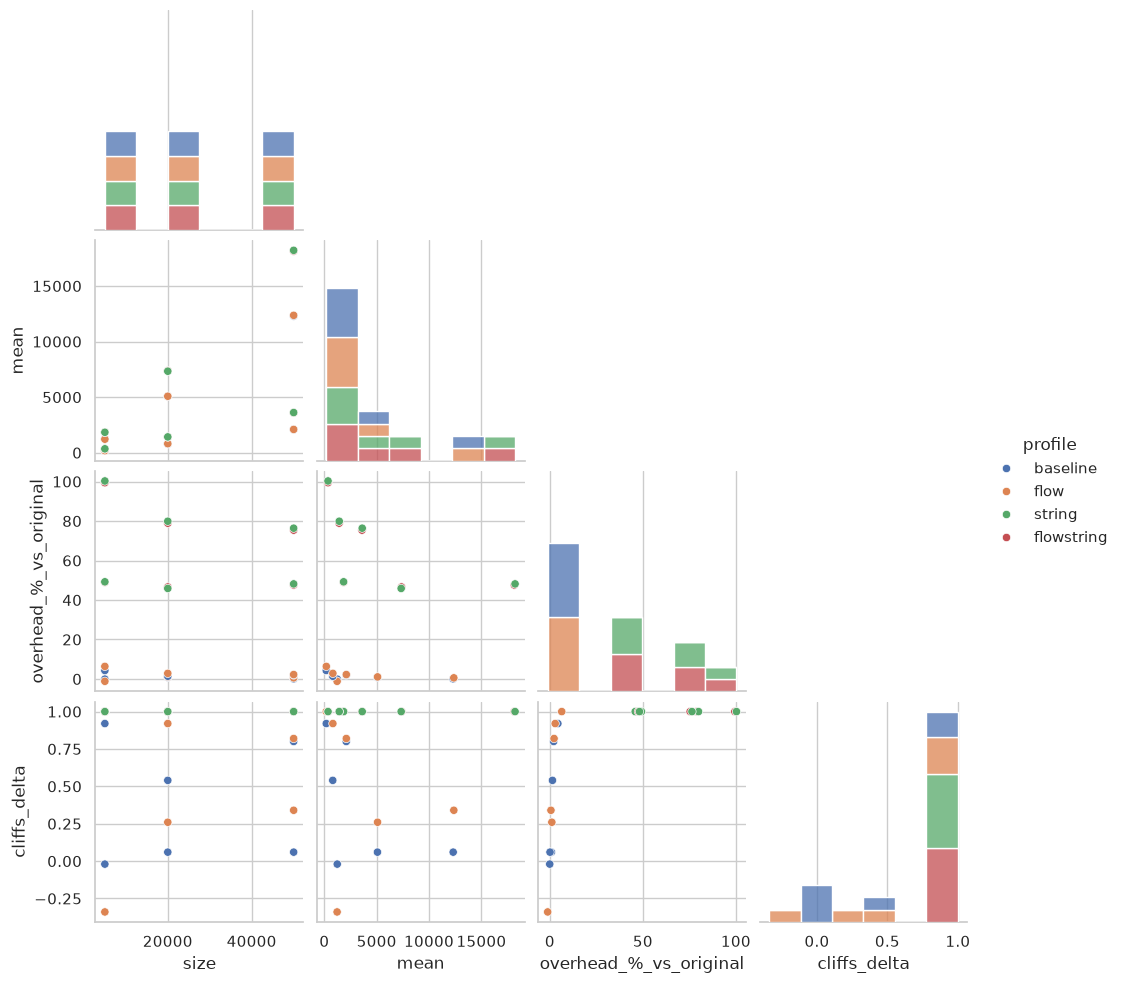

In [21]:
import warnings
warnings.filterwarnings("ignore")

sns.pairplot(
    obf,
    vars=["size", "mean", "overhead_%_vs_original", "cliffs_delta"],
    hue="profile",
    hue_order=["baseline", "flow", "string", "flowstring"],
    diag_kind="hist",
    diag_kws={"multiple": "stack"},
    corner=True,
)
plt.show()

### 6.4 Pearson vs. Spearman

`profile_level` é ordinal, mas o salto de overhead entre `flow` (nível 2) e `string` (nível 3) é uma mudança de patamar, não uma progressão suave — diferente do exemplo `log(x)` da aula de referência (curva perfeitamente monotônica, sem "degraus"), aqui a relação nem é puramente linear nem puramente monotônica-suave.

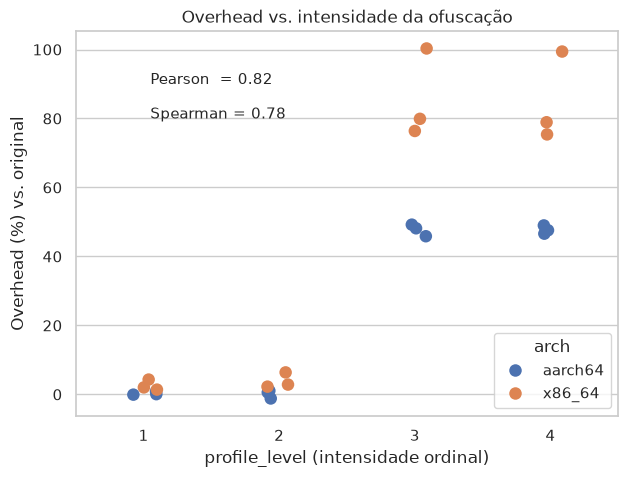

Pearson  = 0.818
Spearman = 0.781


In [22]:
corr_spearman, p_spearman = spearmanr(obf["profile_level"], obf["overhead_%_vs_original"])

plt.figure(figsize=(7, 5))
sns.stripplot(data=obf, x="profile_level", y="overhead_%_vs_original", hue="arch", size=9)
plt.xlabel("profile_level (intensidade ordinal)")
plt.ylabel("Overhead (%) vs. original")
plt.title("Overhead vs. intensidade da ofuscação")
plt.text(0.05, 90, f"Pearson  = {corr_pearson:.2f}", fontsize=11)
plt.text(0.05, 80, f"Spearman = {corr_spearman:.2f}", fontsize=11)
plt.show()

print(f"Pearson  = {corr_pearson:.3f}")
print(f"Spearman = {corr_spearman:.3f}")

Aqui Pearson (≈0,82) é ligeiramente **maior** que Spearman (≈0,78) — o oposto do exemplo `log(x)`. Isso acontece porque Spearman só enxerga a ordem dos postos: para ele, o salto de ~2% (`flow`) para ~66% (`string`) "vale" o mesmo que qualquer outro passo de posto, mesmo sendo desproporcionalmente maior. Pearson, sensível à magnitude, capta melhor esse salto abrupto e concentrado em um único degrau. A lição da Seção 6.5 da aula de referência se confirma na direção oposta: **a forma exata da não linearidade importa**, e nenhuma das duas correlações sozinha conta a história completa sem o gráfico de dispersão acima.

## 7. Por que gráficos são indispensáveis?

Assim como o quarteto de Anscombe mostra que estatísticas-resumo semelhantes podem esconder estruturas visuais muito diferentes, os perfis `baseline` e `flow` deste experimento têm médias e desvios-padrão *agregados* (misturando as duas arquiteturas) parecidos e pequenos — sugerindo, à primeira vista, "ruído sem padrão". Um boxplot separado por arquitetura revela outra história.

In [23]:
leve = obf[obf["profile"].isin(["baseline", "flow"])]

resumo_agregado = leve.groupby("profile", observed=True)["overhead_%_vs_original"].agg(
    media="mean", desvio_padrao="std"
)
print("Estatísticas agregadas (arquiteturas misturadas):")
print(resumo_agregado)
print()
print("% de linhas estatisticamente significativas, por arquitetura:")
print(leve.groupby("arch", observed=True)["significant_5%"].mean())

Estatísticas agregadas (arquiteturas misturadas):
             media  desvio_padrao
profile                          
baseline  1.426667       1.615310
flow      1.990000       2.568315

% de linhas estatisticamente significativas, por arquitetura:
arch
aarch64    0.0
x86_64     1.0
Name: significant_5%, dtype: float64


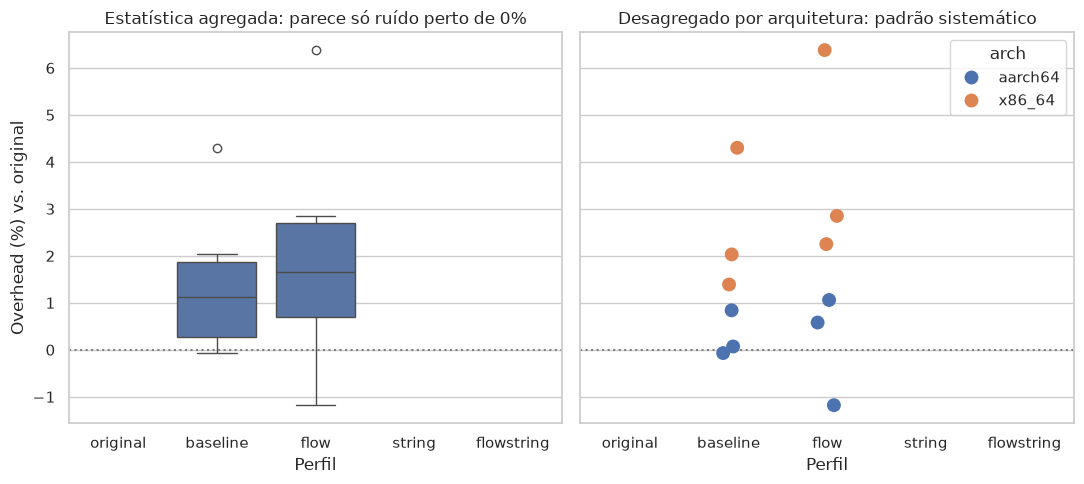

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

sns.boxplot(data=leve, x="profile", y="overhead_%_vs_original", ax=axs[0])
axs[0].axhline(0, color="gray", linestyle=":")
axs[0].set_title("Estatística agregada: parece só ruído perto de 0%")
axs[0].set_xlabel("Perfil")
axs[0].set_ylabel("Overhead (%) vs. original")

sns.stripplot(data=leve, x="profile", y="overhead_%_vs_original", hue="arch", size=10, ax=axs[1])
axs[1].axhline(0, color="gray", linestyle=":")
axs[1].set_title("Desagregado por arquitetura: padrão sistemático")
axs[1].set_xlabel("Perfil")
axs[1].set_ylabel("")

plt.tight_layout()
plt.show()

O boxplot agregado (esquerda) sugere que `baseline`/`flow` oscilam de forma quase simétrica em torno de 0% — "ruído de medição". O gráfico desagregado por arquitetura (direita) mostra que não é ruído: em **aarch64** o overhead realmente é ~0% e nunca significativo (`significant_5%` = 0% das linhas), enquanto em **x86_64** ele é sistematicamente positivo e sempre significativo (100% das linhas) — só invisível na média porque as duas arquiteturas têm o mesmo peso na agregação. Nenhuma dessas duas conclusões aparece na tabela `resumo_agregado` sozinha; só o gráfico desagregado revela a estrutura real dos dados, exatamente como o quarteto de Anscombe.

## 8. Síntese

- O overhead de ofuscação é **bimodal por técnica**: controle de fluxo isolado (`flow`) é quase gratuito (~1–2%); criptografia de strings (`string`, `flowstring`) domina o custo (~46–100%). Combinar as duas técnicas não soma efeitos visíveis — `string` e `flowstring` são estatisticamente quase idênticas.
- `size` não tem associação relevante com o overhead percentual (Pearson ≈ -0,07): o custo relativo da ofuscação não depende do tamanho da carga processada.
- Arquitetura é um fator sistemático e ortogonal ao perfil: x86_64 sempre tem overhead maior que aarch64, para qualquer perfil — inclusive nos casos "leves" (`baseline`/`flow`), onde esse efeito só aparece ao desagregar por `arch` (Seção 7).
- Nenhuma dessas conclusões seria segura só com `describe()` ou uma correlação isolada — cada uma delas precisou de um gráfico (histograma, scatter, boxplot desagregado) para ser confirmada ou refutada, reforçando a lição central desta aula.